# SDE simulation in a periodic potential

Simulate 50 independent trajectories of a one-dimensional stochastic differential equation with Diffrax, then plot the paths.

$$
dX_t = -Ak\sin(kX_t)\,dt + \sigma\,dW_t,
\qquad X_0 = 0.
$$

The drift comes from the periodic potential $V(x)=A[1-\cos(kx)]$. Near $x=0$, the drift is approximately $-Ak^2x$, giving a local Ornstein–Uhlenbeck approximation.


## 1. Imports


In [195]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax


## 2. Model parameters

$A$ controls the potential amplitude, $k$ sets its spatial period $2\pi/k$, and $\sigma$ is the constant diffusion coefficient. Each trajectory has its own Brownian motion.


In [ ]:
A = 1.0
k = 1.0
sigma = 1.1

n_trajectories = 100


## 3. Potential, drift, and diffusion

The deterministic drift points down the potential gradient:

$$
b(x)=-\frac{dV}{dx}=-Ak\sin(kx).
$$

Diffrax expects the drift and diffusion functions to accept `(t, x, args)`.


In [197]:
def V(x):
    """Periodic potential."""
    return A * (1.0 - jnp.cos(k * x))


def drift(t, x, args):
    """Negative gradient of the potential."""
    return -A * k * jnp.sin(k * x)


def diffusion(t, x, args):
    """Constant diffusion coefficient."""
    return sigma


## 4. Time grid and initial condition

`dt` is the solver step size. `ts` contains the 15,000 times at which the solution is saved; its spacing is approximately 0.0333, so it differs from `dt`.


In [198]:
t0 = 0.0
t1 = 500.0
dt = 0.01
x0 = 0.0

ts = jnp.linspace(t0, t1, 15_000)


## 5. Simulate one trajectory

Construct a Brownian path from a random key, combine the drift and diffusion terms, and integrate with the Euler solver. Return the state values at the saved times.


In [199]:
def simulate_one(key):
    """Simulate one trajectory using the supplied random key."""
    brownian = dfx.VirtualBrownianTree(
        t0=t0,
        t1=t1,
        tol=1e-3,
        shape=(),
        key=key,
    )

    terms = dfx.MultiTerm(
        dfx.ODETerm(drift),
        dfx.ControlTerm(diffusion, brownian),
    )

    solution = dfx.diffeqsolve(
        terms,
        dfx.Euler(),
        t0=t0,
        t1=t1,
        dt0=dt,
        y0=x0,
        saveat=dfx.SaveAt(ts=ts),
        max_steps=100_000,
    )
    return solution.ys


## 6. Generate the ensemble

Split the fixed seed into one key per trajectory. `jax.vmap` applies the simulation to all keys. The resulting array has shape `(n_trajectories, len(ts))`, here `(50, 15000)`.


In [200]:
key = jr.PRNGKey(42)
keys = jr.split(key, n_trajectories)

trajectories = jax.vmap(simulate_one)(keys)
print(f"Trajectories shape: {trajectories.shape}")


Trajectories shape: (50, 15000)


## 7. Plot the trajectories

Each line is an independent realization of the same SDE.


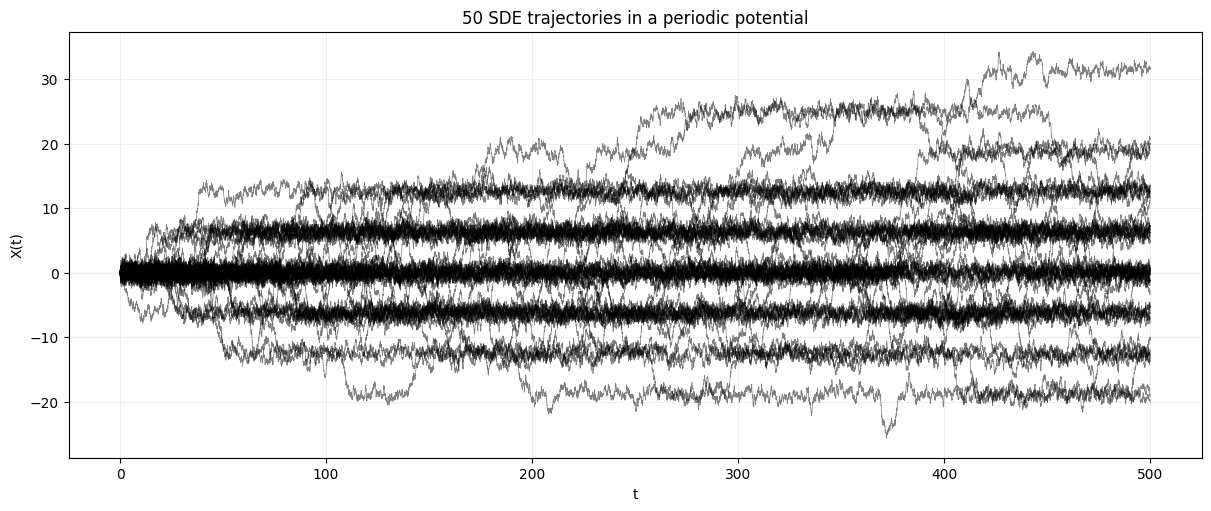

In [201]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for trajectory in trajectories:
    ax.plot(ts, trajectory, color="black", linewidth=0.5, alpha=0.5)

ax.set(
    xlabel="t",
    ylabel="X(t)",
    title=f"{n_trajectories} SDE trajectories in a periodic potential",
)
ax.grid(alpha=0.2)
plt.show()


## 8. Learn drift and diffusion from observed increments

Equinox defines the neural networks, and Optax supplies Adam. For each pair of
consecutive observations, the networks predict the local drift and diffusion.
The loss is the original small-interval Gaussian likelihood approximation:

$$
\Delta X\mid X=x\approx\mathcal N\!\left(b_\theta(x)h,\;s_\theta(x)^2h\right).
$$

Diffrax generates the original data and the final learned path. Training evaluates
the observed increments directly, using their actual elapsed times.

The drift receives `sin(x)` and `cos(x)`, assuming the known spatial period
$2\pi$ ($k=1$). Diffusion receives `x` and is constrained to be positive. Both
networks have four hidden layers of width 64.


In [202]:
class NeuralSDE(eqx.Module):
    drift_net: eqx.nn.MLP
    diffusion_net: eqx.nn.MLP

    def __init__(self, key):
        key_b, key_s = jr.split(key)
        self.drift_net = eqx.nn.MLP(
            in_size=2, out_size=1, width_size=64, depth=4,
            activation=jax.nn.tanh, key=key_b,
        )
        self.diffusion_net = eqx.nn.MLP(
            in_size=1, out_size=1, width_size=64, depth=4,
            activation=jax.nn.tanh, key=key_s,
        )

    def b(self, x):
        phase = jnp.stack([jnp.sin(x), jnp.cos(x)])
        return self.drift_net(phase)[0]

    def s(self, x):
        raw = self.diffusion_net(jnp.atleast_1d(x))[0]
        return jax.nn.softplus(raw) + 1e-3


model = NeuralSDE(jr.PRNGKey(100))


### Prepare consecutive increments

Use the first 40 trajectories for training and reserve the remaining 10 for
validation. Each example contains the starting position, the change to the next
saved position, and elapsed time (approximately 0.0333). The same training arrays
are used for the direct estimates later in the notebook.


In [203]:
train_paths = trajectories[:40]
validation_paths = trajectories[40:]


def make_increments(paths):
    starts = paths[:, :-1]
    return (
        starts.reshape(-1),
        jnp.diff(paths, axis=1).reshape(-1),
        jnp.broadcast_to(jnp.diff(ts), starts.shape).reshape(-1),
    )


x, dx, delta = make_increments(train_paths)
validation_x, validation_dx, validation_delta = make_increments(validation_paths)
print(f"Training increments: {x.size:,}")
print(f"Validation increments: {validation_x.size:,}")


Training increments: 599,960
Validation increments: 149,990


### Score the drift and diffusion predictions

Subtract the expected movement $b_\theta(x)h$ from the observed increment:
$r=\Delta x-b_\theta(x)h$. The per-example loss is

$$
\ell(\theta)=\frac{r^2}{2s_\theta(x)^2h}+\log s_\theta(x).
$$

This is the Gaussian negative log likelihood with terms independent of the model
omitted. The residual term measures how plausible the movement is under the
predicted noise level; the logarithmic term penalizes an excessively large
noise level. Equinox differentiates this expression to train both networks.
The small-interval approximation and interpolation of saved data can affect
parameter estimates.


In [204]:
def loss_fn(model, x_batch, dx_batch, delta_batch):
    b = jax.vmap(model.b)(x_batch)
    s = jax.vmap(model.s)(x_batch)
    residual = dx_batch - b * delta_batch
    return jnp.mean(
        0.5 * residual**2 / (s**2 * delta_batch) + 0.9 * jnp.log(s)
    )


### Update the model with Optax Adam

Equinox differentiates the network's array parameters and keeps activation
functions static during compilation. Optax supplies the Adam updates.

References: [Equinox transformations](https://docs.kidger.site/equinox/api/transformations/) and [Optax Adam](https://optax.readthedocs.io/en/latest/api/generated/optax.adam.html).


In [205]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(model, opt_state, xb, dxb, dtb):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(
        model, xb, dxb, dtb
    )
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_inexact_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


### Train and track validation loss

Use a fixed sample of held-out increments for comparable validation scores.
Validation data never enter parameter updates. Record every training loss and
check validation every 100 updates, including the initial and final model.
The first update compiles the forward and backward computations.


In [206]:
batch_size = 2048
training_steps = 1500
validation_every = 100
validation_size = 4096
validation_indices = jr.randint(
    jr.PRNGKey(102), (validation_size,), 0, validation_x.size
)
validation_batch = (
    validation_x[validation_indices],
    validation_dx[validation_indices],
    validation_delta[validation_indices],
)
evaluate_loss = eqx.filter_jit(loss_fn)
initial_validation_loss = float(evaluate_loss(model, *validation_batch))
print(f"Initial validation loss: {initial_validation_loss:.4f}")

key = jr.PRNGKey(101)
loss_history = []
validation_steps = [0]
validation_history = [initial_validation_loss]
for step in range(training_steps):
    key, batch_key = jr.split(key)
    indices = jr.randint(batch_key, (batch_size,), 0, x.size)
    model, opt_state, loss = train_step(
        model, opt_state,
        x[indices], dx[indices], delta[indices],
    )
    loss_history.append(float(loss))
    completed_steps = step + 1
    if completed_steps % validation_every == 0 or completed_steps == training_steps:
        validation_loss = float(evaluate_loss(model, *validation_batch))
        validation_steps.append(completed_steps)
        validation_history.append(validation_loss)
        print(
            f"Step {completed_steps}: training = {float(loss):.4f}, "
            f"validation = {validation_loss:.4f}"
        )

final_validation_loss = validation_history[-1]


Initial validation loss: 0.9506
Step 100: training = 0.5213, validation = 0.5465
Step 200: training = 0.5153, validation = 0.5458
Step 300: training = 0.5435, validation = 0.5468
Step 400: training = 0.5055, validation = 0.5450
Step 500: training = 0.5360, validation = 0.5457
Step 600: training = 0.5110, validation = 0.5455
Step 700: training = 0.5482, validation = 0.5457
Step 800: training = 0.5032, validation = 0.5460
Step 900: training = 0.5585, validation = 0.5459
Step 1000: training = 0.5371, validation = 0.5472
Step 1100: training = 0.5481, validation = 0.5453
Step 1200: training = 0.5177, validation = 0.5458
Step 1300: training = 0.5348, validation = 0.5463
Step 1400: training = 0.5402, validation = 0.5454
Step 1500: training = 0.5066, validation = 0.5457


## 9. Training progress

Random mini-batches make the training loss noisy. The moving average shows its
trend; validation uses a fixed sample of held-out increments. Lower scores are
better. This Gaussian negative log likelihood omits model-independent terms,
so its values can be negative.


Right-hand y-axis: symlog (base 10); linear only within ±0.0469. Recorded loss range: [0.4694, 0.9506]


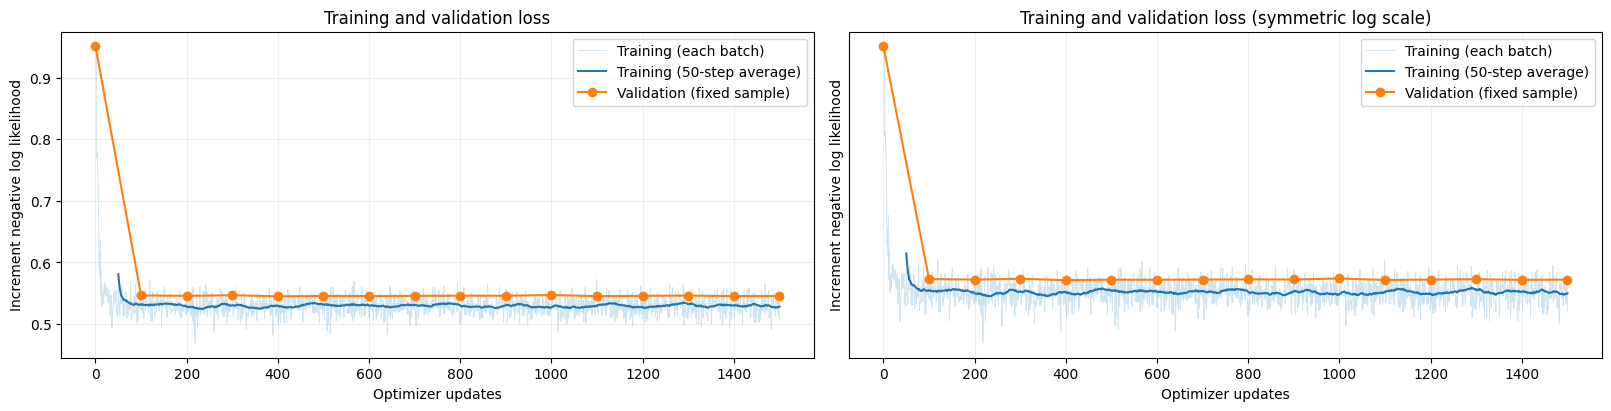

In [207]:
training_losses = np.asarray(loss_history)
training_updates = np.arange(1, len(training_losses) + 1)
smoothing_window = min(50, len(training_losses))
smoothed_loss = np.convolve(
    training_losses, np.ones(smoothing_window) / smoothing_window, mode="valid"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
for ax in axes:
    ax.plot(training_updates, training_losses, color="tab:blue", alpha=0.2,
            linewidth=0.7, label="Training (each batch)")
    ax.plot(training_updates[smoothing_window - 1:], smoothed_loss,
            color="tab:blue", label=f"Training ({smoothing_window}-step average)")
    ax.plot(validation_steps, validation_history, "o-", color="tab:orange",
            label="Validation (fixed sample)")
    ax.set(xlabel="Optimizer updates", ylabel="Increment negative log likelihood")
    ax.grid(alpha=0.2, which="both")
    ax.legend()

axes[0].set_title("Training and validation loss")
# Negative log likelihood can be negative, so use a signed logarithmic scale.
# Keep the linear region below every finite, nonzero recorded loss.
all_losses = np.concatenate((training_losses, np.asarray(validation_history)))
nonzero_magnitudes = np.abs(all_losses[np.isfinite(all_losses) & (all_losses != 0)])
linear_threshold = (
    float(nonzero_magnitudes.min()) / 10 if nonzero_magnitudes.size else 1e-6
)
axes[1].set_yscale("symlog", base=10, linthresh=linear_threshold)
axes[1].set_title("Training and validation loss (symmetric log scale)")
print(
    f"Right-hand y-axis: {axes[1].get_yscale()} (base 10); "
    f"linear only within ±{linear_threshold:.3g}. "
    f"Recorded loss range: [{all_losses.min():.4g}, {all_losses.max():.4g}]"
)
plt.show()


## 10. Learned drift and diffusion

Compare the learned functions with the generating coefficients over the central
98% of training positions. The histogram shows where observations provide
support; estimates in rarely visited regions are less constrained.


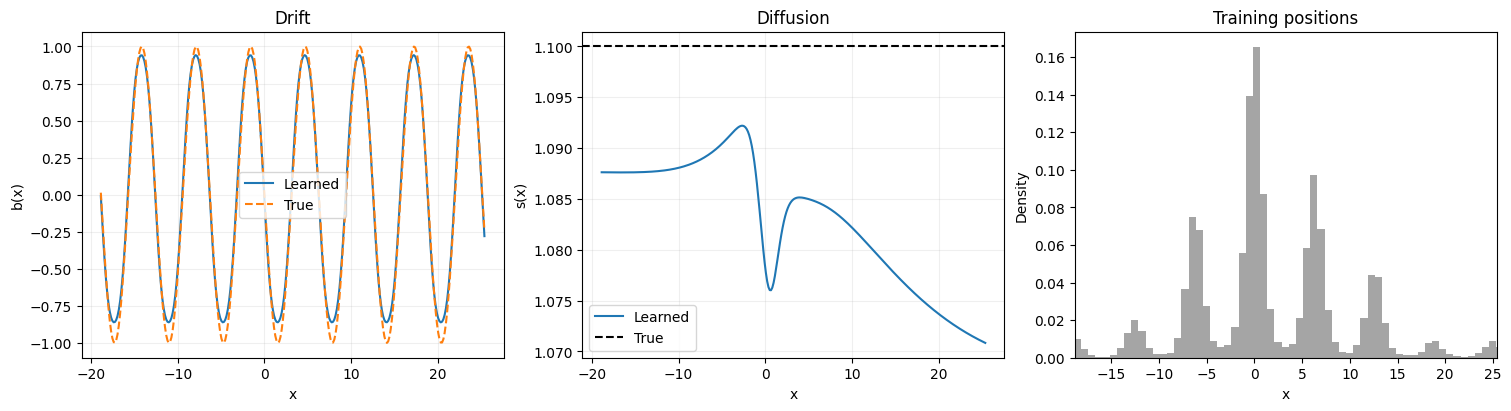

In [208]:
grid = jnp.linspace(jnp.percentile(x, 1), jnp.percentile(x, 99), 300)
learned_b = jax.vmap(model.b)(grid)
learned_s = jax.vmap(model.s)(grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].plot(grid, learned_b, label="Learned")
axes[0].plot(grid, -A * k * jnp.sin(k * grid), "--", label="True")
axes[0].set(xlabel="x", ylabel="b(x)", title="Drift")
axes[1].plot(grid, learned_s, label="Learned")
axes[1].axhline(sigma, linestyle="--", color="black", label="True")
axes[1].set(xlabel="x", ylabel="s(x)", title="Diffusion")
axes[2].hist(np.asarray(x), bins=80, density=True, color="tab:gray", alpha=0.7)
axes[2].set(xlabel="x", ylabel="Density", title="Training positions")
axes[2].set_xlim(float(grid[0]), float(grid[-1]))
for ax in axes[:2]:
    ax.legend()
    ax.grid(alpha=0.2)
plt.show()


## 11. Compare parameter estimates once

Assuming the known $k=1$, project the learned drift onto $-k\sin(kx)$ to obtain an
effective $A$, and average the learned diffusion over observed positions for an
effective $\sigma$. These summarize networks that can represent more general
functions than the original model.

The direct baseline fits the small-interval Gaussian likelihood using the same
40 training trajectories. Its drift fit weights squared residuals by inverse
elapsed time. Both approaches are approximate; numerical saving and finite
observation intervals can affect the estimates.


In [209]:
k_known = 1.0
sample_x = x[::100]
basis_sample = -k_known * jnp.sin(k_known * sample_x)
b_from_net = jax.vmap(model.b)(sample_x)
s_from_net = jax.vmap(model.s)(sample_x)
A_neural = jnp.sum(basis_sample * b_from_net) / jnp.sum(basis_sample**2)
sigma_neural = jnp.mean(s_from_net)

basis = -k_known * jnp.sin(k_known * x)
predictor = basis * delta
A_direct = jnp.sum(predictor * dx / delta) / jnp.sum(predictor**2 / delta)
residual = dx - A_direct * predictor
sigma_direct = jnp.sqrt(jnp.mean(residual**2 / delta))

print(f"{'Method':<20} {'A':>10} {'sigma':>10}")
print("-" * 42)
for name, a_value, s_value in (
    ("Generating values", A, sigma),
    ("Direct estimate", A_direct, sigma_direct),
    ("Neural summary", A_neural, sigma_neural),
):
    print(f"{name:<20} {float(a_value):>10.4f} {float(s_value):>10.4f}")


Method                        A      sigma
------------------------------------------
Generating values        1.0000     1.1000
Direct estimate          0.9059     1.0360
Neural summary           0.9540     1.0832


## 12. Simulate a path from the fitted model

Plot one learned path alongside a held-out observed path. The paths use different
Brownian noise, so their pointwise agreement is not a fitting criterion. Use the
loss and coefficient plots above to assess learning.


In [217]:
def learned_drift(t, x, args):
    return args.b(x)


def learned_diffusion(t, x, args):
    return args.s(x)




def simulate_one_learned(key):
    brownian = dfx.VirtualBrownianTree(
    t0=t0, t1=t1, tol=1e-3, shape=(), key=key
    )
    terms = dfx.MultiTerm(
        dfx.ODETerm(learned_drift),
        dfx.ControlTerm(learned_diffusion, brownian),
    )

    learned_path = dfx.diffeqsolve(
       terms, dfx.Euler(),
       t0=t0, t1=t1, dt0=dt, y0=x0, args=model,
       saveat=dfx.SaveAt(ts=ts),
       max_steps=100_000,
    ).ys
    return learned_path

key = jr.PRNGKey(42)
keys = jr.split(key, n_trajectories)

trajectories_learned = jax.vmap(simulate_one_learned)(keys)
print(f"Trajectories shape: {trajectories_learned.shape}")

Trajectories shape: (50, 15000)


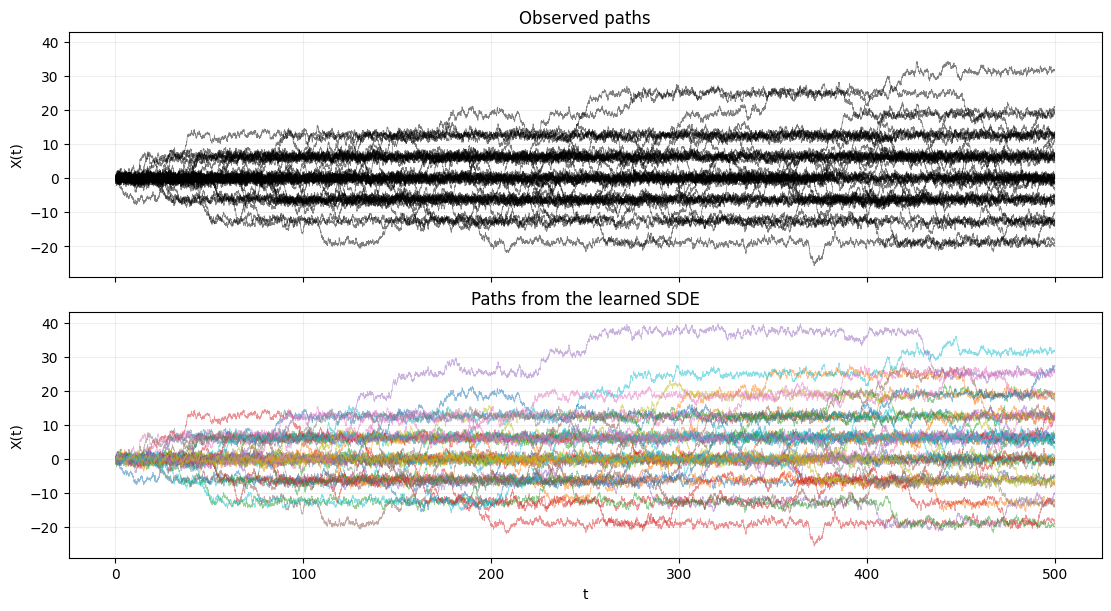

In [219]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, sharey=True,
                         constrained_layout=True)
axes[0].set(ylabel="X(t)", title="Observed paths")
axes[1].set(xlabel="t", ylabel="X(t)", title="Paths from the learned SDE")

for trajectory in trajectories:
    axes[0].plot(ts, trajectory, color="black", linewidth=0.5, alpha=0.5)

for learned_path in trajectories_learned:
    axes[1].plot(ts, learned_path, linewidth=0.5, alpha=0.5)
for ax in axes:
    ax.grid(alpha=0.2)
plt.show()


In [ ]:
from scipy.sparse import diags
from scipy.sparse.linalg import splu


# Finite-time model density: p_t = -(b p)_x + (s^2 p / 2)_xx.
# https://www.stat.cmu.edu/~cshalizi/754/notes/lecture-20.pdf
# This solves the density equation; the curve is not fitted to the endpoints.
def endpoint_model_density(grid, drift_values, diffusion_values, duration, initial):
    spacing = grid[1] - grid[0]
    diffusivity = 0.5 * np.asarray(diffusion_values, dtype=float)**2
    drift_values = np.asarray(drift_values, dtype=float)
    if (not np.isfinite(drift_values).all()
            or not np.isfinite(diffusivity).all() or np.any(diffusivity <= 0)):
        raise ValueError("The density solver requires finite drift and positive diffusion.")

    # Exponentially fitted fluxes preserve nonnegative transition rates.
    peclet = 0.5 * (
        drift_values[:-1] / diffusivity[:-1]
        + drift_values[1:] / diffusivity[1:]
    ) * spacing

    def bernoulli(z):
        result = np.empty_like(z)
        small = np.abs(z) < 1e-5
        large = z > 50
        regular = ~(small | large)
        result[small] = 1 - z[small] / 2 + z[small]**2 / 12
        result[large] = z[large] * np.exp(-z[large])
        result[regular] = z[regular] / np.expm1(z[regular])
        return result

    rate_right = diffusivity[:-1] * bernoulli(-peclet) / spacing**2
    rate_left = diffusivity[1:] * bernoulli(peclet) / spacing**2
    outgoing = np.r_[rate_right, 0] + np.r_[0, rate_left]
    generator = diags(
        [rate_right, -outgoing, rate_left], [-1, 0, 1], format="csc"
    )
    # Reflecting boundaries are placed far into the tails on the shared grid.
    probability = np.zeros(grid.size)
    right = np.searchsorted(grid, initial)
    weight_right = (initial - grid[right - 1]) / spacing
    probability[right - 1] = 1 - weight_right
    probability[right] = weight_right
    time_steps = max(2000, int(np.ceil(duration / 0.25)))
    time_step = duration / time_steps
    solve_step = splu(diags(np.ones(grid.size), format="csc")
                      - time_step * generator).solve
    for _ in range(time_steps):
        probability = solve_step(probability)
    if probability[:10].sum() + probability[-10:].sum() > 1e-5:
        raise ValueError("Density reaches the grid boundaries; increase tail_margin.")
    return probability / spacing


# One endpoint per realization, for the same initial condition and time horizon.
observed_endpoints = np.asarray(trajectories)[:, -1]
learned_endpoints = np.asarray(trajectories_learned)[:, -1]
endpoint_time = float(ts[-1])
endpoint_duration = endpoint_time - float(t0)
all_endpoints = np.concatenate((observed_endpoints, learned_endpoints))
if not np.isfinite(all_endpoints).all():
    raise ValueError("Endpoint distributions require finite simulated endpoints.")

# Use a wide computational domain, but display the region containing endpoints.
tail_margin = 7 * float(sigma) * np.sqrt(endpoint_duration)
density_lower = min(float(all_endpoints.min()), float(x0)) - tail_margin
density_upper = max(float(all_endpoints.max()), float(x0)) + tail_margin
density_spacing = min(0.05, 2 * np.pi / (max(abs(float(k)), 1e-12) * 128))
density_grid = np.linspace(
    density_lower, density_upper,
    int(np.ceil((density_upper - density_lower) / density_spacing)) + 1,
)
observed_density = endpoint_model_density(
    density_grid, -float(A) * float(k) * np.sin(float(k) * density_grid),
    np.full_like(density_grid, float(sigma)), endpoint_duration, float(x0),
)
neural_grid = jnp.asarray(density_grid)
learned_density = endpoint_model_density(
    density_grid, np.asarray(jax.vmap(model.b)(neural_grid)),
    np.asarray(jax.vmap(model.s)(neural_grid)), endpoint_duration, float(x0),
)

endpoint_bins = np.histogram_bin_edges(all_endpoints, bins="auto")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, endpoints, density, label, color in (
    (axes[0], observed_endpoints, observed_density, "Observed", "tab:blue"),
    (axes[1], learned_endpoints, learned_density, "Learned", "tab:orange"),
):
    ax.hist(endpoints, bins=endpoint_bins, density=True, alpha=0.45,
            color=color, edgecolor="white", label=f"Endpoints (n={endpoints.size})")
    ax.plot(density_grid, density, color=color, linewidth=2,
            label="Theoretical density (numerical)")
    ax.set(xlabel="Final position X(T)", ylabel="Probability density",
           title=f"{label} SDE at T = {endpoint_time:g}")
    ax.legend()
    ax.grid(alpha=0.2)
# Show the central model densities as well as all sampled endpoints.
display_limits = [float(all_endpoints.min()), float(all_endpoints.max())]
for density in (observed_density, learned_density):
    cdf = np.cumsum(density) * (density_grid[1] - density_grid[0])
    display_limits[0] = min(display_limits[0], np.interp(0.001, cdf, density_grid))
    display_limits[1] = max(display_limits[1], np.interp(0.999, cdf, density_grid))
axes[0].set_xlim(*display_limits)
plt.show()

print(f"Endpoint summary at T = {endpoint_time:g}")
print(f"{'SDE':<12} {'n':>5} {'Mean':>10} {'Std':>10} "
      f"{'5%':>10} {'Median':>10} {'95%':>10}")
for label, endpoints in (
    ("Observed", observed_endpoints), ("Learned", learned_endpoints)
):
    q05, median, q95 = np.quantile(endpoints, [0.05, 0.5, 0.95])
    std = np.std(endpoints, ddof=1) if endpoints.size > 1 else np.nan
    print(f"{label:<12} {endpoints.size:>5d} {endpoints.mean():>10.4f} "
          f"{std:>10.4f} {q05:>10.4f} {median:>10.4f} {q95:>10.4f}")
